## BACKGROUND

#### PROBLEM STATEMENT

Sampah telah menjadi masalah global terutama di Indonesia. Dari data yang telah didapat mengetahui bahwa terdapat 36 juta ton sampah yang menumpuk setiap tahunnya di Indonesia pada tahun 2022. meskipun angka sampah yang telah terkelola telah mencapai 64% atau 24 juta ton/tahun namun 36% sampah atau 13 juta ton tidak terkelola ini bukanlah angka yang kecil dan harus diperhatikan dengan baik.

#### PROPOSED SOLUTION

Tingginya permintaan masyarakat dalam berbelanja di minimarket yang memberikan kemudahan serta kenyamanan dalam berbelanja menjadi daya tarik utama masyarakat terlebih juga dengan jangkauan yang mudah dan penjualan yang tergolong lengkap. Banyaknya ketersediaan minimarket pada suatu wilayah dalam hal ini Alfamart kini semakin berkembang dalam memperluas jangkauan masyarakat yang tidak ingin pergi ke lokasi toko secara langsung, yaitu dengan membuka toko Alfamart online Alfagift yang menjadi toko online grocery untuk mengakomodir kebutuhan masyarakat Indonesia.

## DATA PREPARATION

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import statsmodels.api as sm
import random as rd
from sklearn.decomposition import PCA
from sklearn.model_selection import ParameterGrid
from matplotlib import colors
from matplotlib.colors import ListedColormap

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Data_Sampah.csv to Data_Sampah.csv


In [ ]:
df = pd.read_csv('Data_Sampah.csv')
#df = pd.read_csv('/content/drive/MyDrive/Data_Sampah.csv')

df = df.rename(columns ={
    'kertas_karbon' : 'kertas_karton'
})
df

,tahun,provinsi,kab_kota,sisa_makanan,kayu_ranting,kertas_karton,plastik,logam,kain,karet_kulit,kaca,jenis_lainnya,sampah_harian,sampah_tahunan
0,2022,Aceh,Kab. Aceh Selatan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.49,"35,217.68"
1,2022,Aceh,Kab. Aceh Tenggara,41.00,11.00,2.00,18.00,2.00,5.00,17.00,4.00,NaN,91.32,"33,332.97"
2,2022,Aceh,Kab. Aceh Timur,37.00,14.00,5.00,26.00,5.00,3.00,2.00,4.00,4.00,173.14,"63,195.95"
3,2022,Aceh,Kab. Aceh Barat,41.80,13.30,10.70,18.20,3.10,2.60,1.80,2.00,6.50,101.43,"37,021.59"
4,2022,Aceh,Kab. Pidie,8.50,7.50,19.30,35.70,4.00,1.00,3.00,2.00,19.00,177.80,"64,897.73"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1033,2019,Papua,Kab. Biak Numfor,5.69,33.75,27.83,14.79,13.19,0.02,0.21,4.52,0.00,58.17,"21,232.05"
1034,2019,Papua,Kota Jayapura,66.39,10.58,4.79,6.60,4.34,2.05,1.08,0.46,3.71,252.63,"92,211.70"
1035,2019,Papua Selatan,Kab. Asmat,15.00,10.00,30.00,20.00,5.00,5.00,5.00,5.00,5.00,39.00,"14,233.54"
1036,2019,Papua Barat Daya,Kab. Raja Ampat,0.00,0.00,0.00,0.00,0.00,NaN,NaN,0.00,NaN,33.13,"12,090.99"


Data diatas merupakan data mentah yang belum diolah, belum diketahui apakah terdapat null dan duplikat atau tidak

## DATA UNDERSTANDING

#### DATA DESCRIPTION


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038 entries, 0 to 1037
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tahun           1038 non-null   int64  
 1   provinsi        1038 non-null   object 
 2   kab_kota        1038 non-null   object 
 3   sisa_makanan    794 non-null    float64
 4   kayu_ranting    766 non-null    float64
 5   kertas_karton   804 non-null    float64
 6   plastik         804 non-null    float64
 7   logam           778 non-null    float64
 8   kain            749 non-null    float64
 9   karet_kulit     706 non-null    float64
 10  kaca            752 non-null    float64
 11  jenis_lainnya   748 non-null    float64
 12  sampah_harian   1038 non-null   object 
 13  sampah_tahunan  1038 non-null   object 
dtypes: float64(9), int64(1), object(4)
memory usage: 113.7+ KB


Dari data description diatas dapat diambil insight bahwa sampah_harian dan sampah_tahunan masih berbentuk object dan harus diubah menjadi float64

In [ ]:
df.head()

,tahun,provinsi,kab_kota,sisa_makanan,kayu_ranting,kertas_karton,plastik,logam,kain,karet_kulit,kaca,jenis_lainnya,sampah_harian,sampah_tahunan
0,2022,Aceh,Kab. Aceh Selatan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.49,"35,217.68"
1,2022,Aceh,Kab. Aceh Tenggara,41.0,11.0,2.0,18.0,2.0,5.0,17.0,4.0,NaN,91.32,"33,332.97"
2,2022,Aceh,Kab. Aceh Timur,37.0,14.0,5.0,26.0,5.0,3.0,2.0,4.0,4.0,173.14,"63,195.95"
3,2022,Aceh,Kab. Aceh Barat,41.8,13.3,10.7,18.2,3.1,2.6,1.8,2.0,6.5,101.43,"37,021.59"
4,2022,Aceh,Kab. Pidie,8.5,7.5,19.3,35.7,4.0,1.0,3.0,2.0,19.0,177.80,"64,897.73"


In [ ]:
df.nunique()

tahun                5
provinsi            38
kab_kota           385
sisa_makanan       352
kayu_ranting       313
kertas_karton      297
plastik            321
logam              219
kain               202
karet_kulit        171
kaca               198
jenis_lainnya      259
sampah_harian     1004
sampah_tahunan    1018
dtype: int64

In [ ]:
df.describe()

,tahun,sisa_makanan,kayu_ranting,kertas_karton,plastik,logam,kain,karet_kulit,kaca,jenis_lainnya
count,1038.000000,794.000000,766.000000,804.000000,804.000000,778.000000,749.000000,706.000000,752.000000,748.000000
mean,2020.591522,40.501549,14.211684,11.751679,17.587226,3.203548,2.583258,1.953484,2.266210,7.118316
std,1.146377,19.345355,14.626894,6.937976,8.902255,4.088914,2.401677,2.113876,2.174724,10.565757
min,2018.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020.000000,27.370000,5.000000,7.170000,11.800000,0.980000,1.000000,0.535000,1.000000,1.700000
50%,2021.000000,41.000000,10.000000,10.430000,16.700000,2.000000,2.000000,1.245000,1.795000,4.900000
75%,2022.000000,55.780000,17.722500,14.660000,21.890000,4.000000,3.500000,2.500000,2.962500,8.500000
max,2022.000000,83.000000,86.000000,40.300000,63.000000,45.000000,19.000000,17.000000,17.380000,100.000000


In [ ]:
df.isnull().sum()

tahun               0
provinsi            0
kab_kota            0
sisa_makanan      244
kayu_ranting      272
kertas_karton     234
plastik           234
logam             260
kain              289
karet_kulit       332
kaca              286
jenis_lainnya     290
sampah_harian       0
sampah_tahunan      0
dtype: int64

Dari hasil tersebut, terdapat null yang lumayan banyak pada beberapa variabel, maka dari itu perlu dilakukan data cleansing.

## DATA CLEANSING

In [ ]:
df[df.duplicated()]

,tahun,provinsi,kab_kota,sisa_makanan,kayu_ranting,kertas_karton,plastik,logam,kain,karet_kulit,kaca,jenis_lainnya,sampah_harian,sampah_tahunan


In [ ]:
df['sisa_makanan'] = df['sisa_makanan'].fillna(value=df['sisa_makanan'].mean())
df['kayu_ranting'] = df['kayu_ranting'].fillna(value=df['kayu_ranting'].mean())
df['kertas_karton'] = df['kertas_karton'].fillna(value=df['kertas_karton'].mean())
df['plastik'] = df['plastik'].fillna(value=df['plastik'].mean())
df['logam'] = df['logam'].fillna(value=df['logam'].mean())
df['kain'] = df['kain'].fillna(value=df['kain'].mean())
df['karet_kulit'] = df['karet_kulit'].fillna(value=df['karet_kulit'].mean())
df['kaca'] = df['kaca'].fillna(value=df['kaca'].mean())
df['jenis_lainnya'] = df['jenis_lainnya'].fillna(value=df['jenis_lainnya'].mean())

df = round(df, 2)
df

,tahun,provinsi,kab_kota,sisa_makanan,kayu_ranting,kertas_karton,plastik,logam,kain,karet_kulit,kaca,jenis_lainnya,sampah_harian,sampah_tahunan
0,2022,Aceh,Kab. Aceh Selatan,40.50,14.21,11.75,17.59,3.20,2.58,1.95,2.27,7.12,96.49,"35,217.68"
1,2022,Aceh,Kab. Aceh Tenggara,41.00,11.00,2.00,18.00,2.00,5.00,17.00,4.00,7.12,91.32,"33,332.97"
2,2022,Aceh,Kab. Aceh Timur,37.00,14.00,5.00,26.00,5.00,3.00,2.00,4.00,4.00,173.14,"63,195.95"
3,2022,Aceh,Kab. Aceh Barat,41.80,13.30,10.70,18.20,3.10,2.60,1.80,2.00,6.50,101.43,"37,021.59"
4,2022,Aceh,Kab. Pidie,8.50,7.50,19.30,35.70,4.00,1.00,3.00,2.00,19.00,177.80,"64,897.73"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1033,2019,Papua,Kab. Biak Numfor,5.69,33.75,27.83,14.79,13.19,0.02,0.21,4.52,0.00,58.17,"21,232.05"
1034,2019,Papua,Kota Jayapura,66.39,10.58,4.79,6.60,4.34,2.05,1.08,0.46,3.71,252.63,"92,211.70"
1035,2019,Papua Selatan,Kab. Asmat,15.00,10.00,30.00,20.00,5.00,5.00,5.00,5.00,5.00,39.00,"14,233.54"
1036,2019,Papua Barat Daya,Kab. Raja Ampat,0.00,0.00,0.00,0.00,0.00,2.58,1.95,0.00,7.12,33.13,"12,090.99"


Variabel yang terdapat nilai null telah diperbaiki dengan diisi oleh mean tiap variabel

In [ ]:
df = df[df['tahun'] != 2018]
df

,tahun,provinsi,kab_kota,sisa_makanan,kayu_ranting,kertas_karton,plastik,logam,kain,karet_kulit,kaca,jenis_lainnya,sampah_harian,sampah_tahunan
0,2022,Aceh,Kab. Aceh Selatan,40.50,14.21,11.75,17.59,3.20,2.58,1.95,2.27,7.12,96.49,"35,217.68"
1,2022,Aceh,Kab. Aceh Tenggara,41.00,11.00,2.00,18.00,2.00,5.00,17.00,4.00,7.12,91.32,"33,332.97"
2,2022,Aceh,Kab. Aceh Timur,37.00,14.00,5.00,26.00,5.00,3.00,2.00,4.00,4.00,173.14,"63,195.95"
3,2022,Aceh,Kab. Aceh Barat,41.80,13.30,10.70,18.20,3.10,2.60,1.80,2.00,6.50,101.43,"37,021.59"
4,2022,Aceh,Kab. Pidie,8.50,7.50,19.30,35.70,4.00,1.00,3.00,2.00,19.00,177.80,"64,897.73"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1032,2019,Maluku Utara,Kota Tidore Kepulauan,34.00,25.00,12.00,11.80,2.30,0.80,1.50,5.80,6.80,45.39,"16,568.81"
1033,2019,Papua,Kab. Biak Numfor,5.69,33.75,27.83,14.79,13.19,0.02,0.21,4.52,0.00,58.17,"21,232.05"
1034,2019,Papua,Kota Jayapura,66.39,10.58,4.79,6.60,4.34,2.05,1.08,0.46,3.71,252.63,"92,211.70"
1035,2019,Papua Selatan,Kab. Asmat,15.00,10.00,30.00,20.00,5.00,5.00,5.00,5.00,5.00,39.00,"14,233.54"


Alasan kami menghapus baris pada tahun 2018, karena pada Tahun 2018 hanya terdapat data di 1 provinsi yaitu Provinsi Papua Barat dan dalam baris tersebut nilainya terlalu kecil.

In [ ]:
# Misalkan sampah_tahunan adalah sebuah Series dalam DataFrame
# Mengganti tanda koma (,) dengan kosong ('') pada seluruh data dalam Series
df['sampah_tahunan'] = df['sampah_tahunan'].str.replace(',', '')

# Mengganti tanda titik (.) yang tidak diperlukan dengan kosong ('') pada seluruh data dalam Series
df['sampah_tahunan'] = df['sampah_tahunan'].str.replace('.', '', regex=False)

# Mengonversi nilai menjadi tipe data float
df['sampah_tahunan'] = df['sampah_tahunan'].astype(float)



In [ ]:
# Misalkan sampah_harian adalah sebuah Series dalam DataFrame
# Mengganti tanda koma (,) dengan kosong ('') pada seluruh data dalam Series
df['sampah_harian'] = df['sampah_harian'].str.replace(',', '')

# Mengganti tanda titik (.) yang tidak diperlukan dengan kosong ('') pada seluruh data dalam Series
df['sampah_harian'] = df['sampah_harian'].str.replace('.', '', regex=False)

# Mengonversi nilai menjadi tipe data float
df['sampah_harian'] = df['sampah_harian'].astype(float)

Hasil ini mengubah tipe data sampah harian dan sampah tahunan menjadi float, dimana sebelumnya merupakan tipe data object.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1037 entries, 0 to 1036
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tahun           1037 non-null   int64  
 1   provinsi        1037 non-null   object 
 2   kab_kota        1037 non-null   object 
 3   sisa_makanan    1037 non-null   float64
 4   kayu_ranting    1037 non-null   float64
 5   kertas_karton   1037 non-null   float64
 6   plastik         1037 non-null   float64
 7   logam           1037 non-null   float64
 8   kain            1037 non-null   float64
 9   karet_kulit     1037 non-null   float64
 10  kaca            1037 non-null   float64
 11  jenis_lainnya   1037 non-null   float64
 12  sampah_harian   1037 non-null   float64
 13  sampah_tahunan  1037 non-null   float64
dtypes: float64(11), int64(1), object(2)
memory usage: 121.5+ KB


Data sampah_harian dan sampah_tahunan diatas berhasil diubah dari object menjadi float64

In [ ]:
df.isnull().sum()

tahun             0
provinsi          0
kab_kota          0
sisa_makanan      0
kayu_ranting      0
kertas_karton     0
plastik           0
logam             0
kain              0
karet_kulit       0
kaca              0
jenis_lainnya     0
sampah_harian     0
sampah_tahunan    0
dtype: int64

Data kosong atau null sudah diisi oleh rata-rata dari tiap entitas

## DATA VISUALIZATION

#### BREAKDOWN SAMPAH PER TAHUN

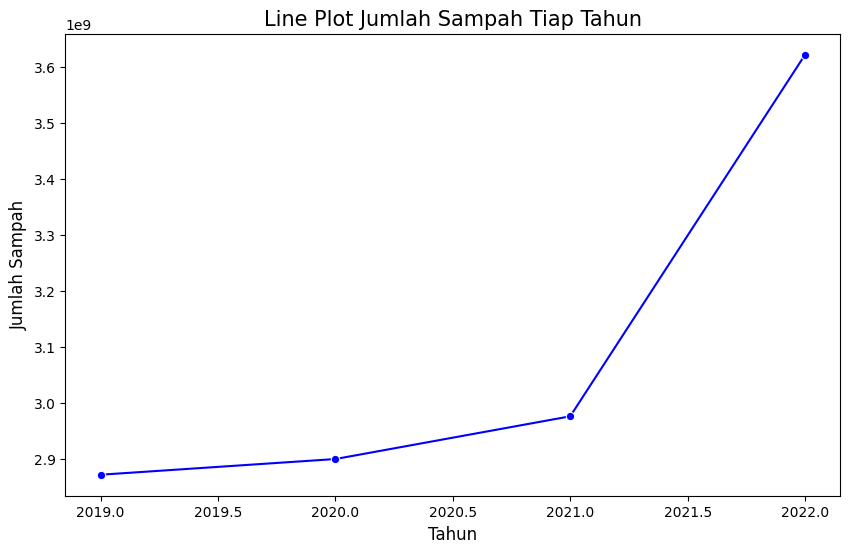

In [ ]:
df_gabung = df.groupby('tahun').sum().reset_index()
df_gabung

plt.figure(figsize=(10,6))
sns.lineplot(data=df_gabung, x='tahun', y='sampah_tahunan', marker='o', color='blue')
plt.title('Line Plot Jumlah Sampah Tiap Tahun', fontsize=15)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Jumlah Sampah', fontsize=12)
plt.show()

Berdasarkan hasil visualisasi di atas menggunakan line plot tingkat jumlah sampah dari tahun 2019-2022, sumbu x menunjukkan angka tahun, dan sumbu y yang menunjukkan jumlah sampah. Terlihat pada tahun 2022 mengalami kelonjakan yang sangat signifikan dibandingkan tahun-tahun sebelumnya.

Text(0.5, 1.0, 'Distribusi Sampah di Tiap Provinsi')

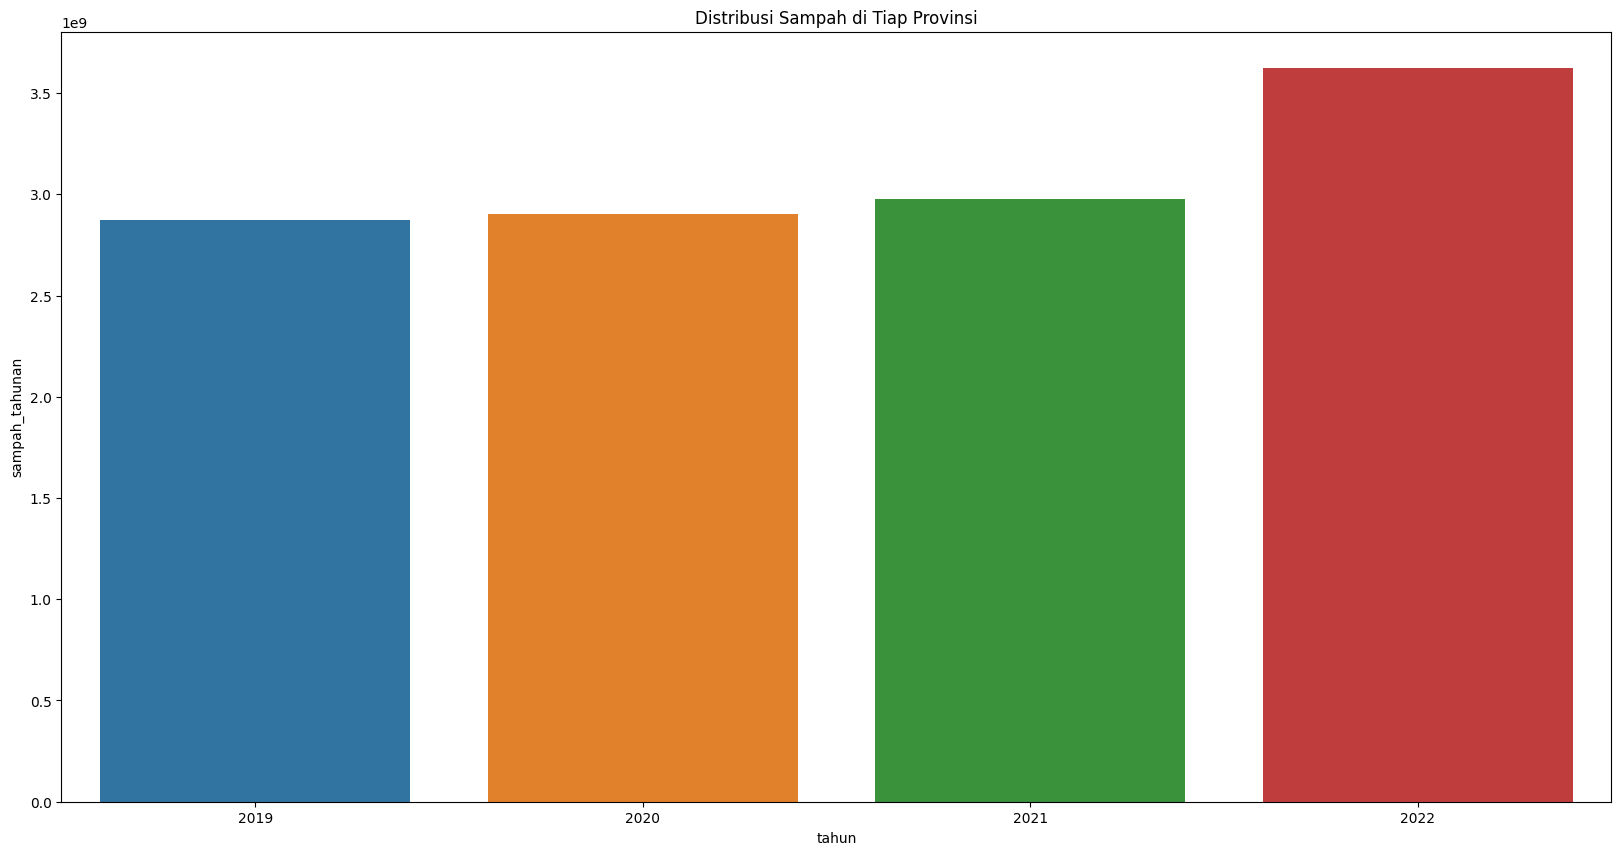

In [ ]:
plt.figure(figsize=(20,10))
sns.barplot(y='sampah_tahunan',data=df_gabung, x='tahun')
plt.title('Distribusi Sampah di Tiap Provinsi')

Barplot diatas memberikan gambaran visual tentang bagaimana jumlah sampah berubah dari tahun ke tahun di berbagai provinsi. Dari Bar plot diatas, dapat diambil insight bahwa sampah tahunan periode 2019 - 2022 selalu meningkat setiap tahunnya.

#### BARPLOT PENYEBARAN SAMPAH TAHUNAN (2019-2022)

<Axes: xlabel='sampah_tahunan', ylabel='provinsi'>

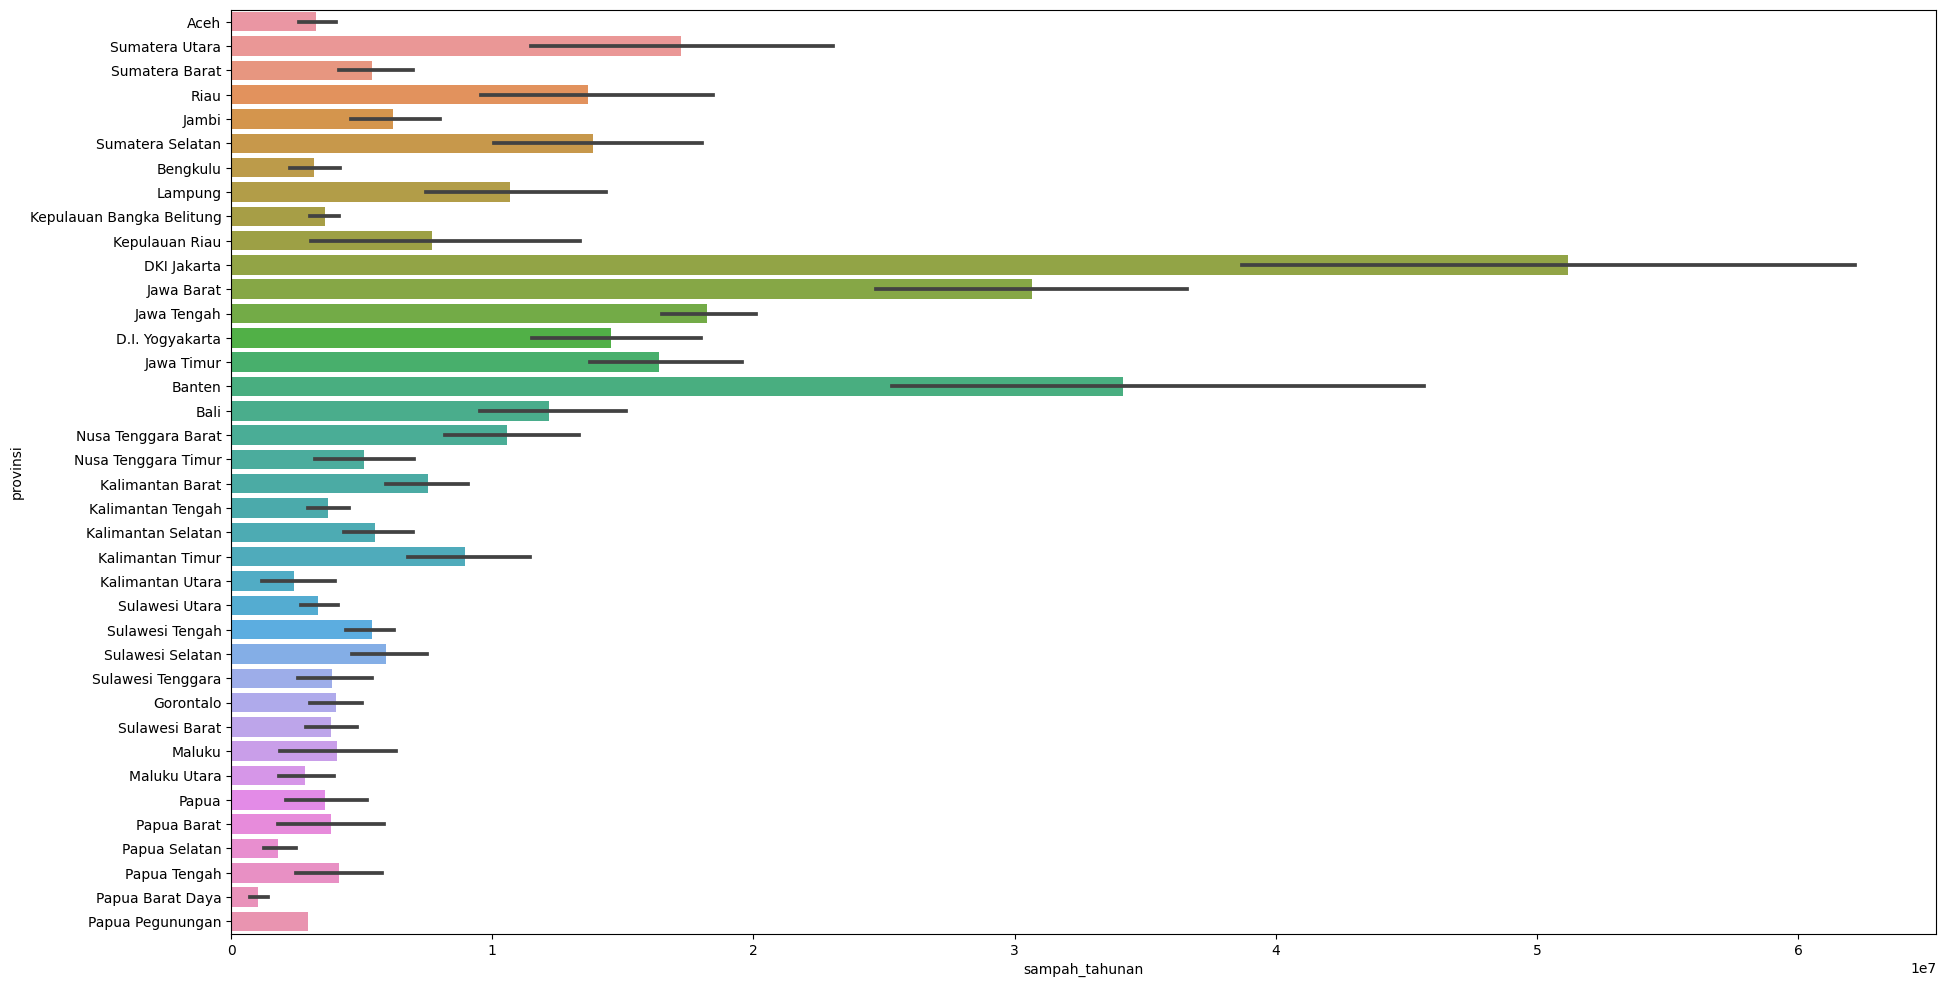

In [ ]:
plt.figure(figsize=(22,12))
sns.barplot(data=df, y='provinsi', x='sampah_tahunan')

Dari bar plot diatas, dapat diambil kesimpulan bahwa DKI Jakarta adalah Provinsi dengan sampah tahunan paling banyak selama periode 2019-2022, dan Papua Barat Daya adalah Provinsi dengan sampah tahunan paling sedikit selama periode 2019-2022

#### BARPLOT PENYEBARAN SAMPAH HARIAN (2019-2022)

<Axes: xlabel='sampah_harian', ylabel='provinsi'>

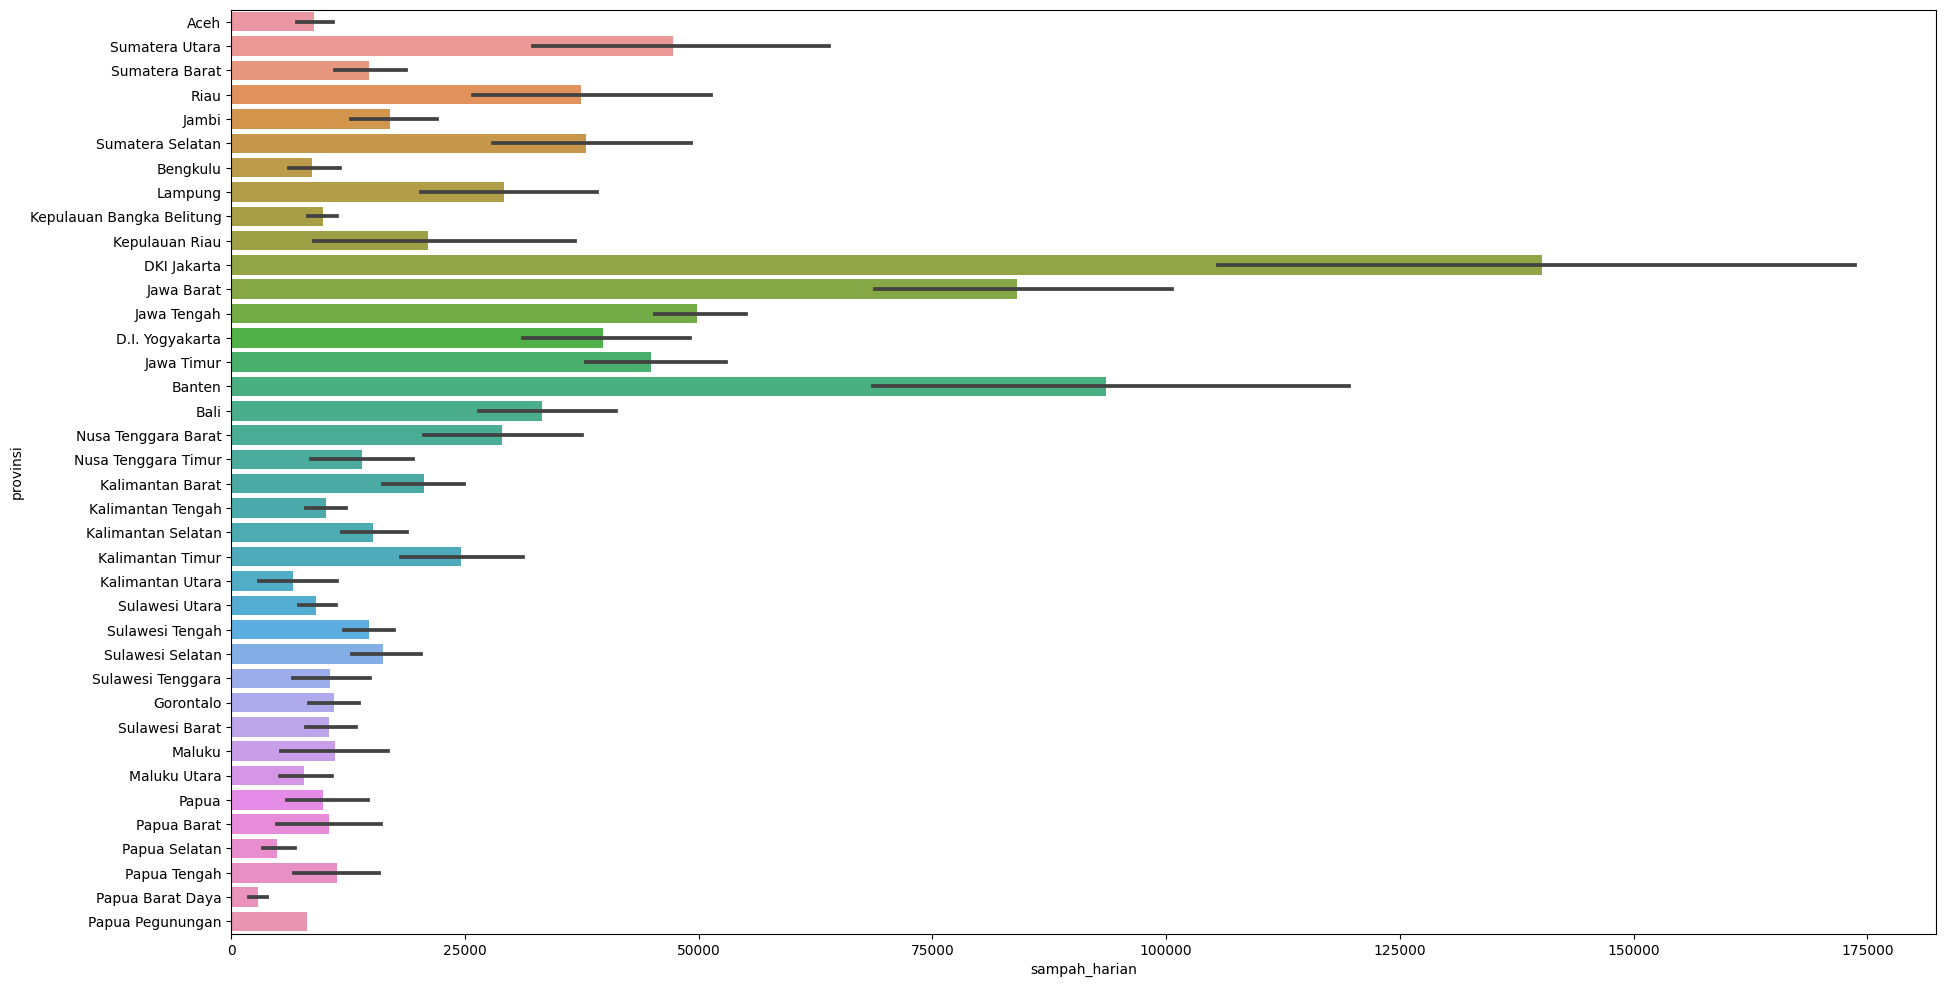

In [ ]:
plt.figure(figsize=(22,12))
sns.barplot(data=df, y='provinsi', x='sampah_harian')

Dari bar plot diatas, dapat diambil kesimpulan bahwa DKI Jakarta adalah Provinsi dengan sampah harian paling banyak selama periode 2019-2022, dan Papua Barat Daya adalah Provinsi dengan sampah harian paling sedikit selama periode 2019-2022

## UNIVARIATE ANALYSIS

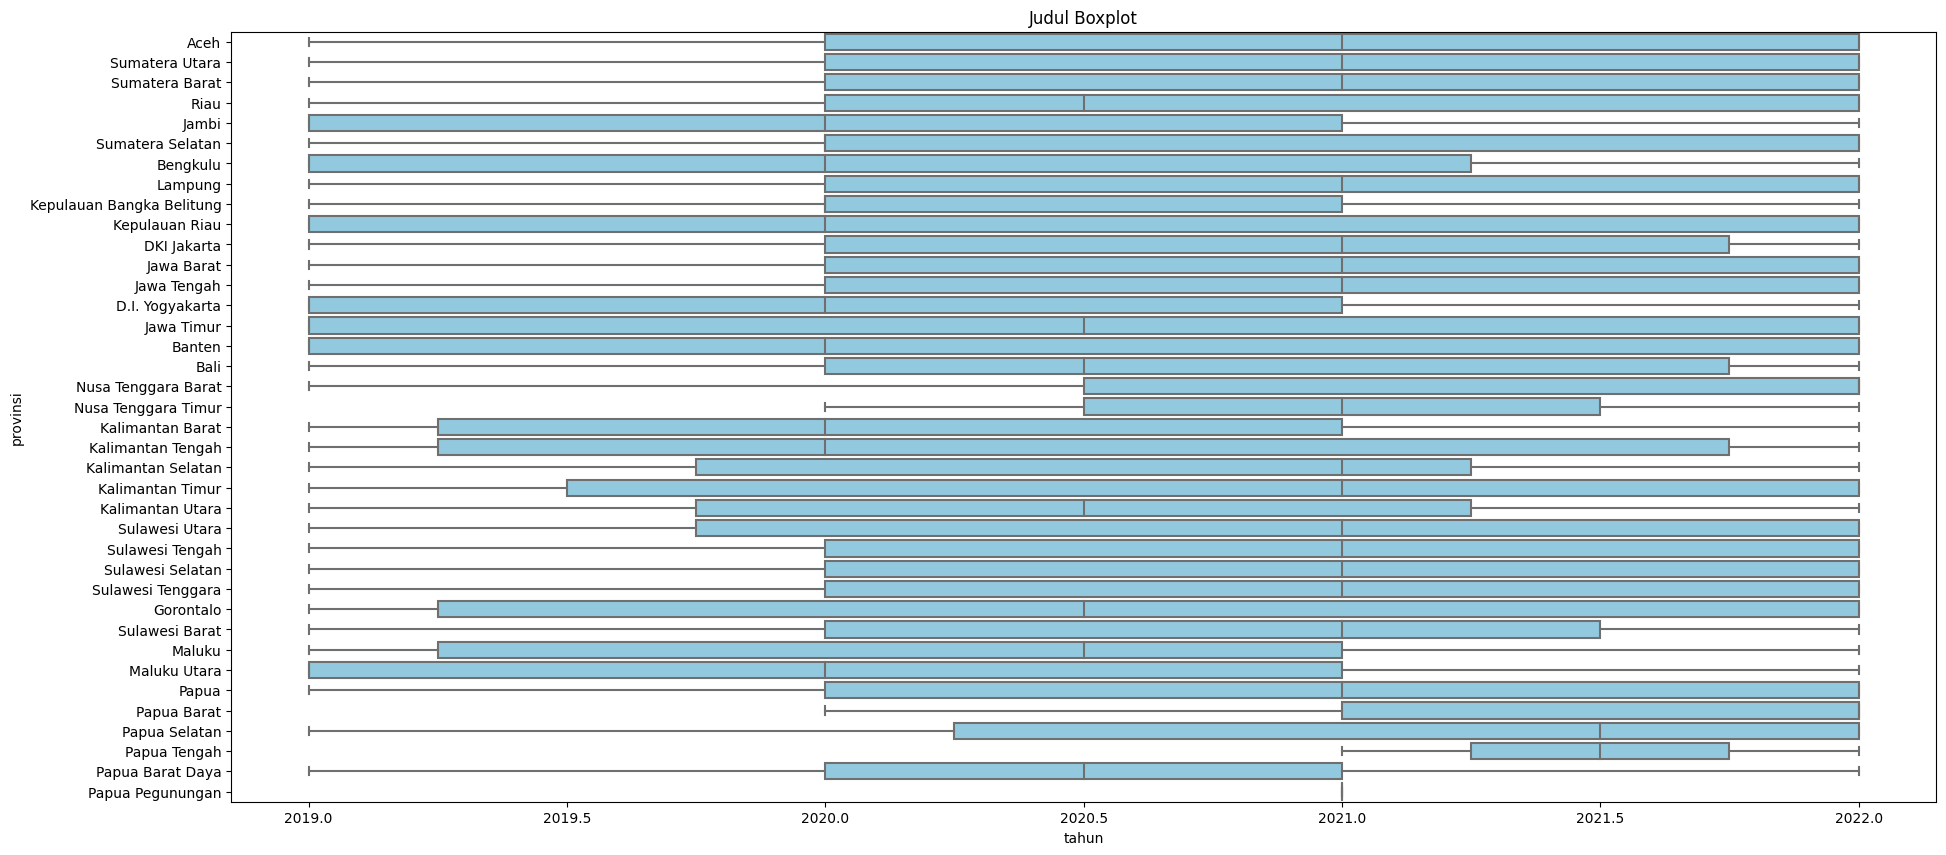

In [ ]:
plt.figure(figsize=(22, 10))
sns.boxplot(data=df,x='tahun',y='provinsi', color='skyblue')
plt.title('Judul Boxplot')
plt.show()

Boxplot diatas adalah distribusi provinsi per tahun

In [ ]:
# Mengonversi 'sampah_harian' ke tipe data numerik
if df['sampah_harian'].dtype == 'O':
    df['sampah_harian'] = pd.to_numeric(df['sampah_harian'].str.replace(',', ''), errors='coerce')

rata_rata_sampah      =df['sampah_harian'].mean()
std_deviasi_sampah    =df['sampah_harian'].std()
nilai_terbanyak_sampah=df['sampah_harian'].mode()[0]
nilai_minimum_sampah  =df['sampah_harian'].min()
nilai_maksimum_sampah =df['sampah_harian'].max()
rentang_sampah        =nilai_maksimum_sampah - nilai_minimum_sampah

print(f"Rata-rata Jumlah Sampah Harian: {round(rata_rata_sampah, 2)}")
print(f"Standar Deviasi Jumlah Sampah Harian: {round(std_deviasi_sampah,2)}")
print(f"Nilai yang Paling Sering Muncul (Mode): {round(nilai_terbanyak_sampah,2)}")
print(f"Nilai Minimum Jumlah Sampah Harian: {round(nilai_minimum_sampah,2)}")
print(f"Nilai Maksimum Jumlah Sampah Harian: {round(nilai_maksimum_sampah,2)}")
print(f"Rentang Nilai Jumlah Sampah Harian: {round(rentang_sampah,2)}")

Rata-rata Jumlah Sampah Harian: 32685.44
Standar Deviasi Jumlah Sampah Harian: 40392.59
Nilai yang Paling Sering Muncul (Mode): 9459.0
Nilai Minimum Jumlah Sampah Harian: 1135.0
Nilai Maksimum Jumlah Sampah Harian: 266055.0
Rentang Nilai Jumlah Sampah Harian: 264920.0


In [ ]:
# Data sampah di atas rata-rata per kota
data_diatas_rata_rata_per_kota = df[df['sampah_harian'] > rata_rata_sampah].groupby('kab_kota').agg({
    'sampah_harian': ['mean', 'count']
}).reset_index()

print(data_diatas_rata_rata_per_kota)

                   kab_kota  sampah_harian      
                                      mean count
0               Kab. Asahan   54617.250000     4
1               Kab. Badung   32733.000000     1
2              Kab. Bandung  129094.666667     3
3               Kab. Banjar   40807.500000     2
4               Kab. Bantul   54100.500000     2
..                      ...            ...   ...
110           Kota Surabaya  200327.000000     4
111          Kota Surakarta   37629.000000     1
112          Kota Tangerang  148260.000000     2
113  Kota Tangerang Selatan   96838.000000     4
114         Kota Yogyakarta   35005.000000     3

[115 rows x 3 columns]


In [ ]:
kota_diatas_rata_rata = df[df['sampah_harian'] > rata_rata_sampah].groupby('kab_kota').size().reset_index(name='Count')

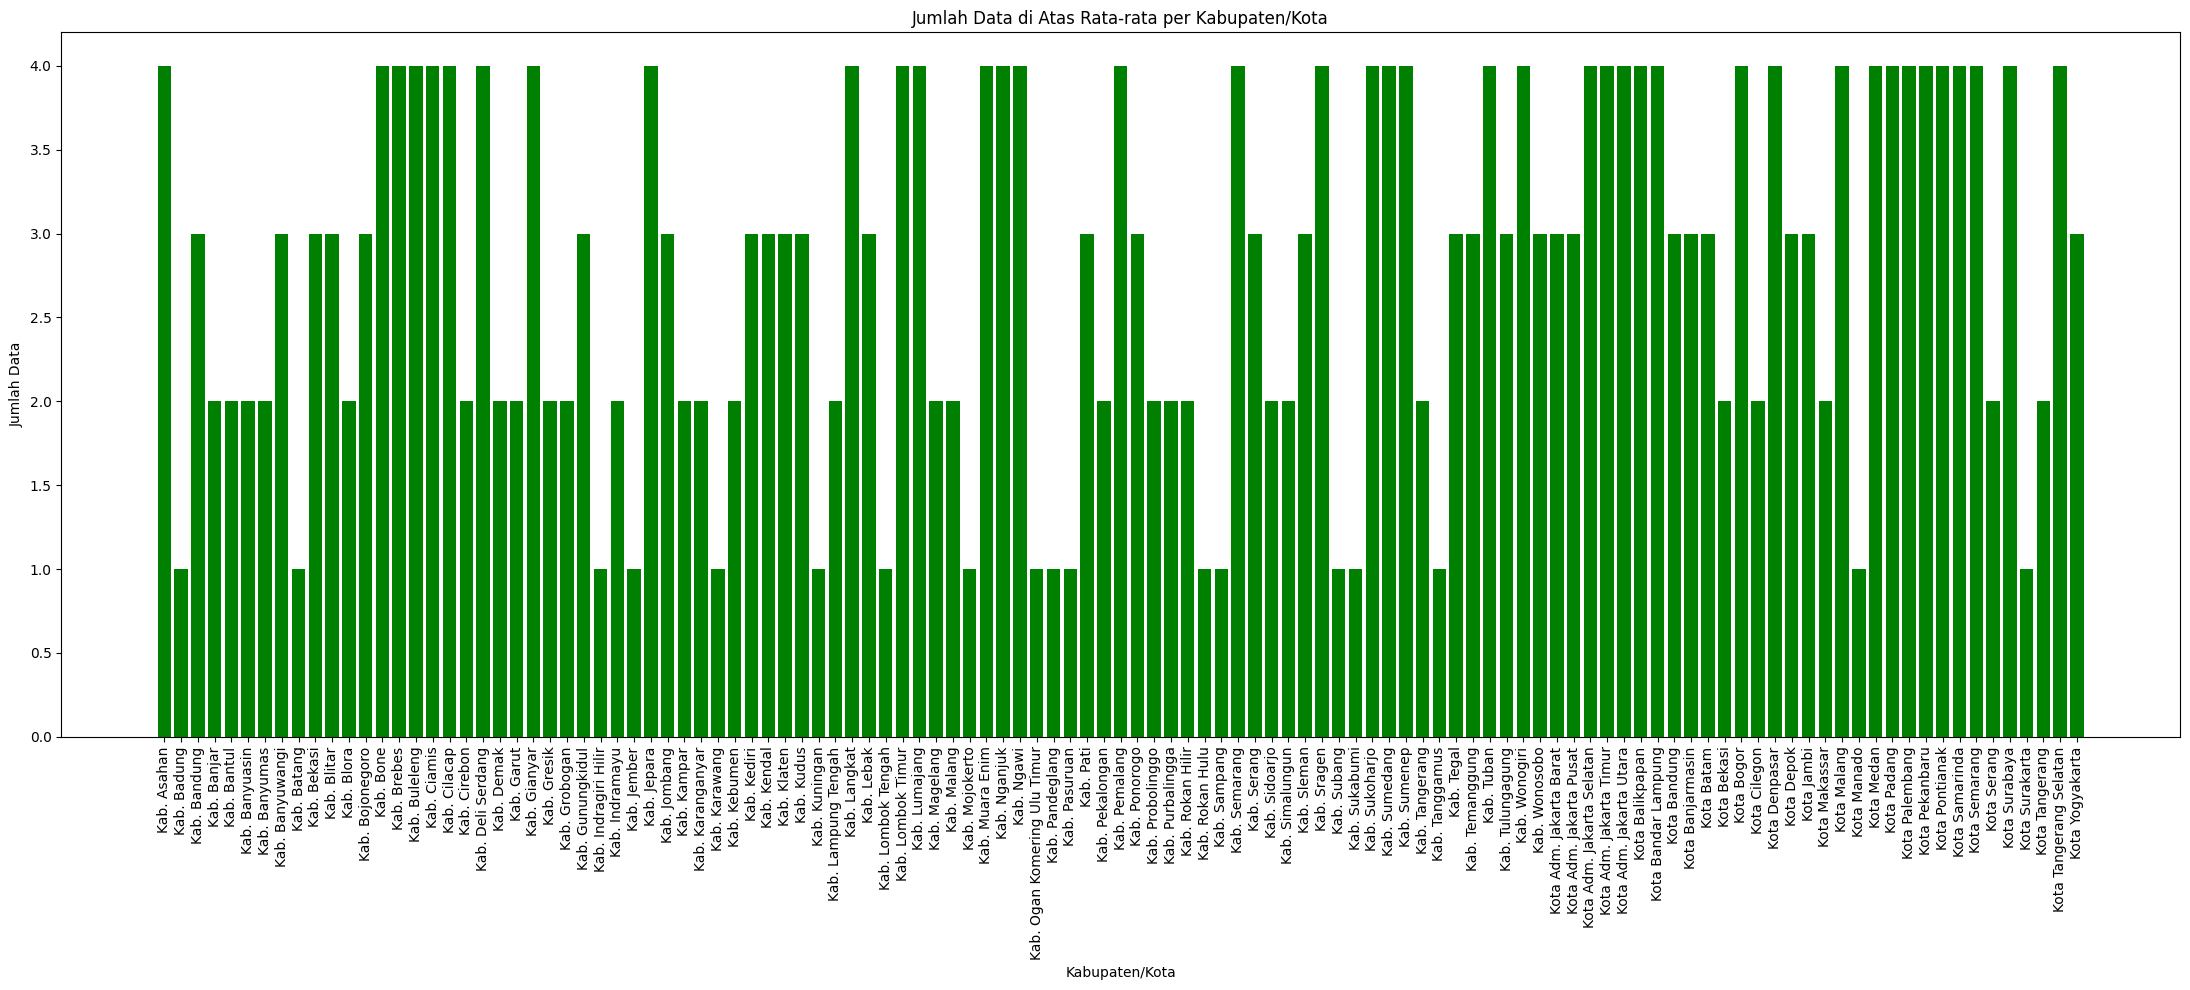

In [ ]:
#JUMLAH DATA KOTA YANG MEMILIKI NILAI DI ATAS RATA-RATA
plt.figure(figsize=(22, 10))
plt.bar(kota_diatas_rata_rata['kab_kota'], kota_diatas_rata_rata['Count'], color='green')
plt.xlabel('Kabupaten/Kota')
plt.ylabel('Jumlah Data')
plt.title('Jumlah Data di Atas Rata-rata per Kabupaten/Kota')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Chart di atas digunakan untuk memvisualisasikan jumlah data (Count) di setiap kabupaten/kota yang memiliki nilai 'sampah_harian' di atas rata-rata. Visualisasi ini membantu untuk memahami distribusi data dan memberikan gambaran tentang sebaran kota-kota dengan tingkat sampah harian di atas rata-rata.

## BIVARIATE ANALYSIS

In [ ]:
#membuat data frame baru
df_selected = df

#membuat kolom baru
df_selected['anorganik'] = df['kertas_karton'] + df['plastik'] + df['logam'] + df['kain'] + df['karet_kulit'] + df['kaca']
df_selected['organik'] = df['sisa_makanan'] + df['kayu_ranting']

#mengelompokan data berdasarkan provinsi
df_selected = df_selected.groupby('provinsi').sum().reset_index()

df_selected

,provinsi,tahun,sisa_makanan,kayu_ranting,kertas_karton,plastik,logam,kain,karet_kulit,kaca,jenis_lainnya,sampah_harian,sampah_tahunan,anorganik,organik
0,Aceh,80834,1187.34,610.44,415.80,769.59,227.32,193.78,176.83,134.20,295.57,355534.0,1.297690e+08,1917.52,1797.78
1,Bali,60616,685.87,1253.44,276.44,510.83,77.95,71.12,67.57,57.28,208.70,998787.0,3.645562e+08,1061.19,1939.31
2,Banten,42431,891.63,318.81,240.05,385.56,59.98,49.16,40.42,63.23,132.31,1964089.0,7.168928e+08,838.40,1210.44
3,Bengkulu,24242,468.85,297.41,135.86,156.02,41.70,17.31,19.35,21.05,70.44,103727.0,3.786094e+07,391.29,766.26
4,D.I. Yogyakarta,32324,833.54,181.08,169.30,268.37,48.09,21.33,21.03,54.53,100.67,636942.0,2.324841e+08,582.65,1014.62
5,DKI Jakarta,44454,870.31,299.09,227.11,340.57,60.52,55.33,40.69,44.20,292.30,3084704.0,1.125918e+09,768.42,1169.40
6,Gorontalo,20206,372.68,151.24,142.01,217.99,33.60,26.32,24.80,28.10,56.26,110007.0,4.015259e+07,472.82,523.92
7,Jambi,46466,900.68,297.27,292.85,411.60,108.91,64.72,77.41,38.32,228.13,390451.0,1.425152e+08,993.81,1197.95
8,Jawa Barat,105072,2269.97,667.73,615.86,900.19,134.03,151.46,81.27,159.31,459.18,4370875.0,1.595368e+09,2042.12,2937.70
9,Jawa Tengah,208129,4238.04,1554.54,1190.14,1879.36,283.71,269.95,171.66,242.10,625.97,5136805.0,1.874934e+09,4036.92,5792.58


Dari kodingan diatas, anorganik adalah sampah yang terdiri dari kertas karton, plastik, logam, kain, karet kulit, dan kaca. Sedangkan organik adalah sampah yang terdiri dari sisa makanan dan kayu ranting

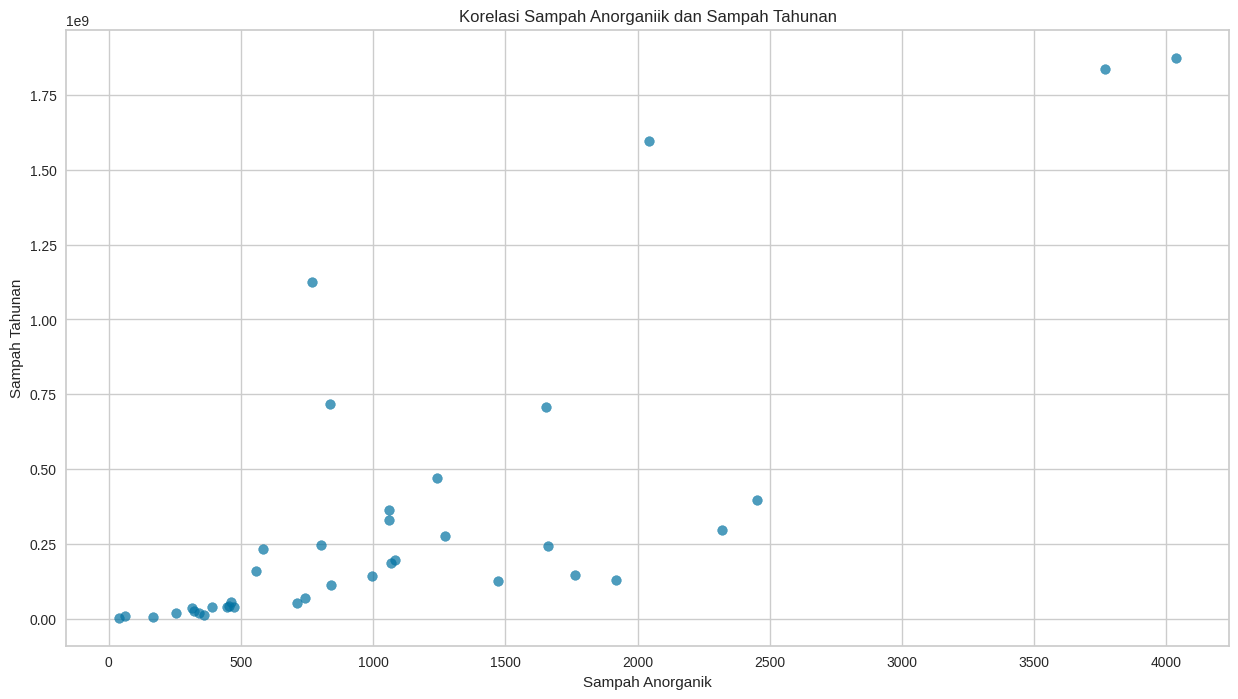

In [ ]:
plt.figure(figsize=(15, 8))
plt.scatter(df_selected['anorganik'], df_selected['sampah_tahunan'], alpha=0.7)
plt.title('Korelasi Sampah Anorganiik dan Sampah Tahunan')
plt.xlabel('Sampah Anorganik')
plt.ylabel('Sampah Tahunan')
plt.grid(True)
plt.show()

Dari Scatter Plot diatas, dapat diambil insight bahwa sampah anorganik dan sampah tahunan memiliki korelasi positif, artinya semakin banyak jumlah sampah tahunan, maka semakin banyak juga jumlah sampah anorganik nya.

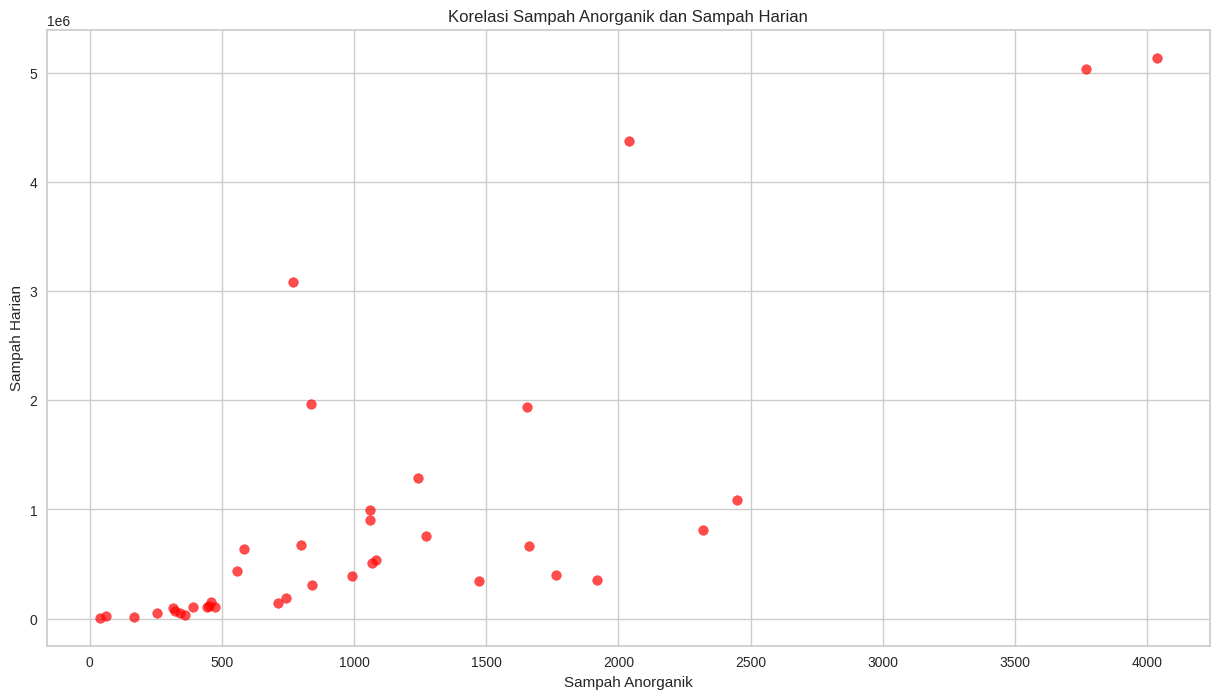

In [ ]:
plt.figure(figsize=(15, 8))
plt.scatter(df_selected['anorganik'], df_selected['sampah_harian'], alpha=0.7, color='red')
plt.title('Korelasi Sampah Anorganik dan Sampah Harian')
plt.xlabel('Sampah Anorganik')
plt.ylabel('Sampah Harian')
plt.grid(True)
plt.show()

Dari Scatter Plot diatas, dapat diambil insight bahwa sampah anorganik dan sampah harian memiliki korelasi positif, artinya semakin banyak jumlah sampah harian, maka semakin banyak juga jumlah sampah anorganik nya.

## SUPERVISED LEARNING

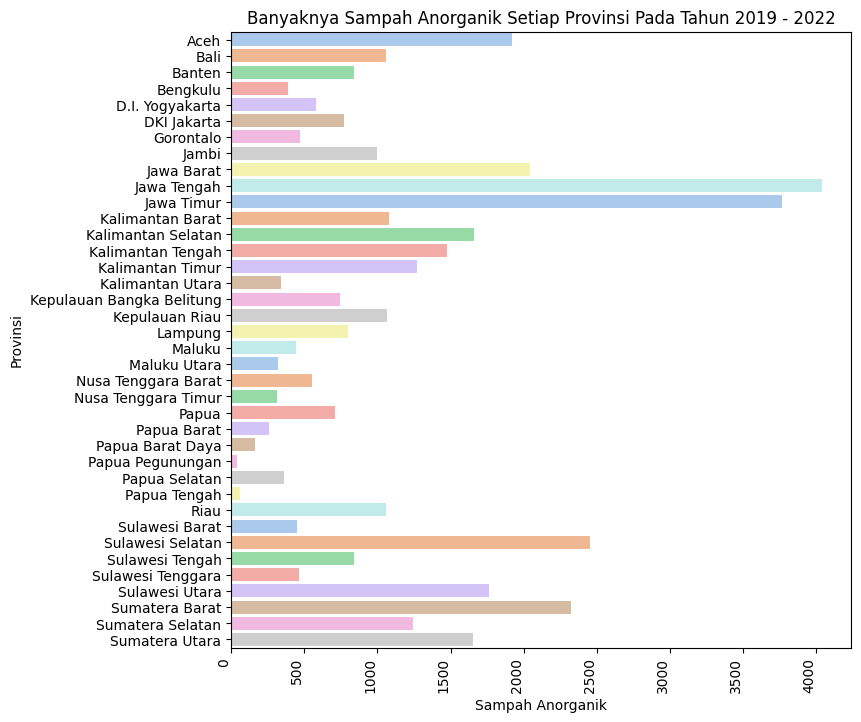

In [ ]:
# Membuat barplot berdasarkan provinsi menggunakan seaborn
plt.figure(figsize=(8, 8))
sns.barplot(y='provinsi', x='anorganik', data=df_selected, palette='pastel')
plt.xticks(rotation=90, ha='right')
plt.title('Banyaknya Sampah Anorganik Setiap Provinsi Pada Tahun 2019 - 2022')
plt.ylabel('Provinsi')
plt.xlabel('Sampah Anorganik')
plt.show()

Dari hasil visualisasi diatas, mengenai banyaknya sampah anorganik setiap provinsi pada tahun 2019-2022, dapat diambil kesimpulan bahwa Provinsi Jawa Tengah memiliki jumlah sampah anorganik yang paling tinggi dan Papua Pegunungan memiliki jumlah sampah anorganik yang paling rendah.

#### LINEAR REGRESSION SAMPAH TAHUNAN

In [ ]:
#Menghitung korelasi sampah jenis karton dan plastik dengan sampah tahunan
data=df_selected[['anorganik','sampah_tahunan']]

data.columns = ['x','y']
data.head()

#Membuat data menjadi array sesuai dengan kebutuhan model
x = data.x.values.reshape(-1,1)
y = data.y.values.reshape(-1,1)

#Model Linear Regression
model = LinearRegression().fit(x, y)

#Menghitung b0 dan b1
b0 = float(model.intercept_[0])
b0 = round(b0,3)
b1 = float(model.coef_[0][0])
b1 = round(b1,3)

#Menampilkan hasil
print('intercept (b0 ): ', b0)
print('slope (b1) : ', b1)
print(' ')
textstr = 'y = '+str(b0)+' + '+str(b1)+' * x'
print(textstr)

intercept (b0 ):  -113744778.04
slope (b1) :  409245.976
 
y = -113744778.04 + 409245.976 * x


Kode di atas mengimplementasikan linear regression untuk mengevaluasi hubungan antara sampah jenis karton atau plastik ('anorganik') dengan jumlah sampah tahunan ('sampah_tahunan').ini digunakan untuk membuat prediksi tentang jumlah sampah tahunan berdasarkan data sampah jenis karton atau plastik

Text(0, 0.5, 'Sampah Tahunan')

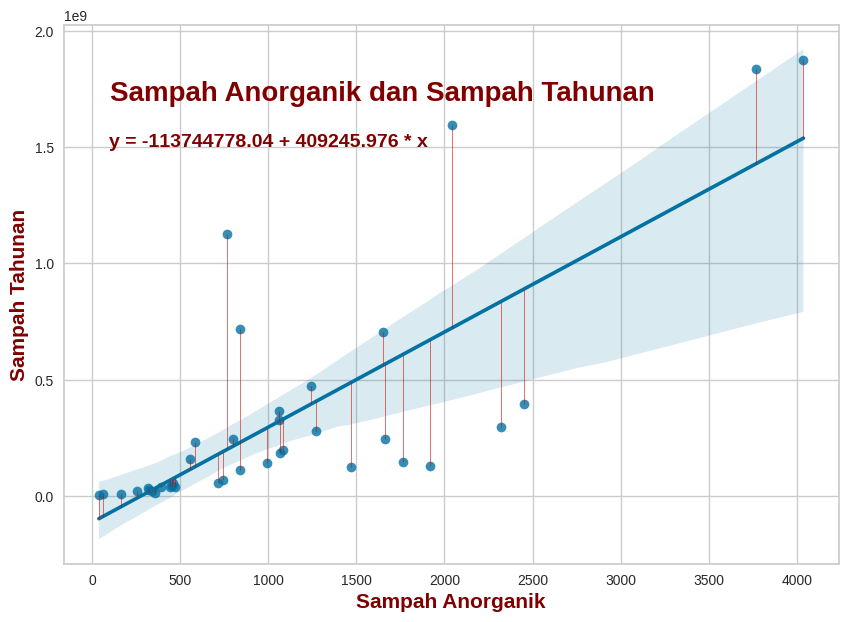

In [ ]:
fit = np.polyfit(data['x'], data['y'], deg=1)
y_hat = fit[1] + data['x'] * fit[0]

fig, ax = plt.subplots(figsize=(10,7))
sns.regplot(x='x', y='y', data=data)
plt.vlines(data['x'], y_hat, data['y'], lw = .4, colors='r')

title = 'Sampah Anorganik dan Sampah Tahunan'
ax.text(100,1700000000,title,horizontalalignment='left',color='#800000',fontsize=20,fontweight='bold')
ax.text(1000,1500000000,textstr,horizontalalignment='center',color='#800000',fontsize=14,fontweight='bold')
ax.set_xlabel('Sampah Anorganik',color='#800000',fontsize=15,fontweight='bold')
ax.set_ylabel('Sampah Tahunan', color='#800000',fontsize=15, fontweight='bold')

Garis regresi pada visualisasi di atas naik, ini mencerminkan hubungan linier positif antara variabel sampah anorganik dan sampah tahunan. Dengan kata lain,  ketika jumlah Sampah Anorganik meningkat, jumlah Sampah Tahunan juga meningkat.



#### LINEAR REGRESSION SAMPAH HARIAN

In [ ]:
#Menghitung korelasi sampah jenis karton dan plastik dengan sampah tahunan
data=df_selected[['anorganik','sampah_harian']]

data.columns = ['x','y']
data.head()

#Membuat data menjadi array sesuai dengan kebutuhan model
x = data.x.values.reshape(-1,1)
y = data.y.values.reshape(-1,1)

#Model Linear Regression
model = LinearRegression().fit(x, y)

#Menghitung b0 dan b1
b0 = float(model.intercept_[0])
b0 = round(b0,3)
b1 = float(model.coef_[0][0])
b1 = round(b1,3)

#Menampilkan hasil
print('intercept (b0 ): ', b0)
print('slope (b1) : ', b1)
print(' ')
textstr = 'y = '+str(b0)+' + '+str(b1)+' * x'
print(textstr)

intercept (b0 ):  -311629.475
slope (b1) :  1121.222
 
y = -311629.475 + 1121.222 * x


Text(0, 0.5, 'Sampah Harian')

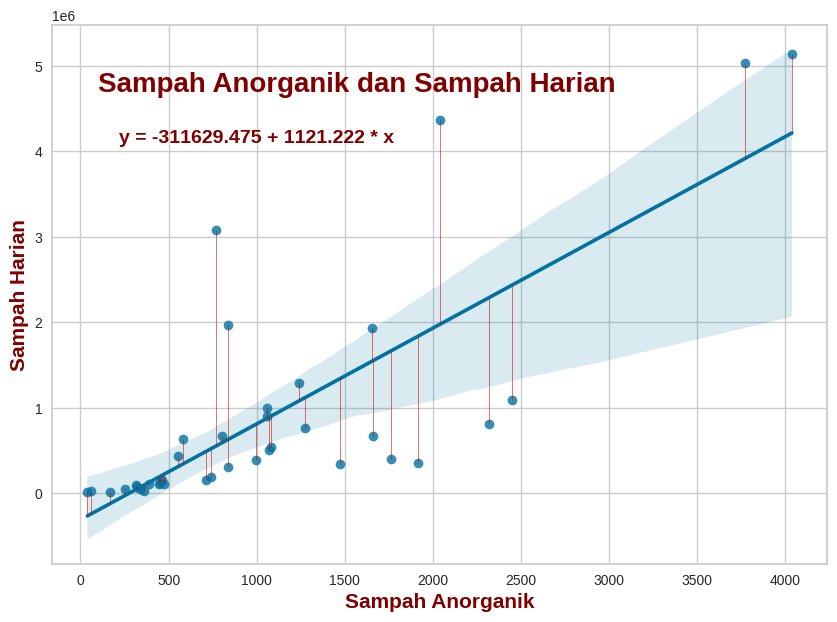

In [ ]:
fit = np.polyfit(data['x'], data['y'], deg=1)
y_hat = fit[1] + data['x'] * fit[0]

fig, ax = plt.subplots(figsize=(10,7))
sns.regplot(x='x', y='y', data=data)
plt.vlines(data['x'], y_hat, data['y'], lw = .4, colors='r')

title = 'Sampah Anorganik dan Sampah Harian'
ax.text(100,4700000,title,horizontalalignment='left',color='#800000',fontsize=20,fontweight='bold')
ax.text(1000,4100000,textstr,horizontalalignment='center',color='#800000',fontsize=14,fontweight='bold')
ax.set_xlabel('Sampah Anorganik',color='#800000',fontsize=15,fontweight='bold')
ax.set_ylabel('Sampah Harian', color='#800000',fontsize=15, fontweight='bold')

Garis regresi pada visualisasi di atas naik, ini mencerminkan hubungan linier positif antara variabel sampah anorganik dan sampah harian. Dengan kata lain, ketika jumlah Sampah meningkat, jumlah Sampah anorganik juga meningkat.

#### LINEAR REGRESSION ANORGANIK & ORGANIK

In [ ]:
#Menghitung korelasi sampah jenis karton dan plastik dengan sampah tahunan
data=df_selected[['anorganik','organik']]

data.columns = ['x','y']
data.head()

#Membuat data menjadi array sesuai dengan kebutuhan model
x = data.x.values.reshape(-1,1)
y = data.y.values.reshape(-1,1)

#Model Linear Regression
model = LinearRegression().fit(x, y)

#Menghitung b0 dan b1
b0 = float(model.intercept_[0])
b0 = round(b0,3)
b1 = float(model.coef_[0][0])
b1 = round(b1,3)

#Menampilkan hasil
print('intercept (b0 ): ', b0)
print('slope (b1) : ', b1)
print(' ')
textstr = 'y = '+str(b0)+' + '+str(b1)+' * x'
print(textstr)

intercept (b0 ):  -129.941
slope (b1) :  1.512
 
y = -129.941 + 1.512 * x


Text(0, 0.5, 'Sampah Organik')

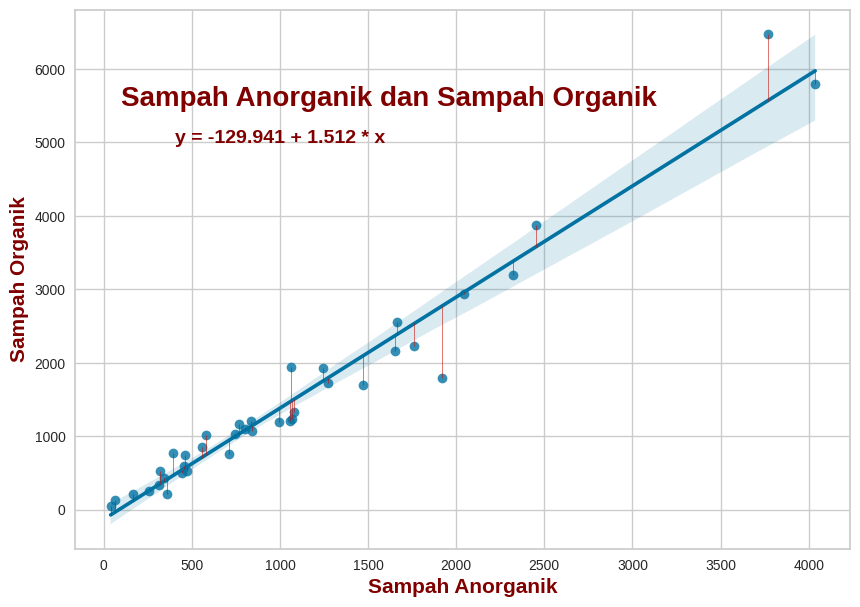

In [ ]:
fit = np.polyfit(data['x'], data['y'], deg=1)
y_hat = fit[1] + data['x'] * fit[0]

fig, ax = plt.subplots(figsize=(10,7))
sns.regplot(x='x', y='y', data=data)
plt.vlines(data['x'], y_hat, data['y'], lw = .4, colors='r')

title = 'Sampah Anorganik dan Sampah Organik'
ax.text(100,5500,title,horizontalalignment='left',color='#800000',fontsize=20,fontweight='bold')
ax.text(1000,5000,textstr,horizontalalignment='center',color='#800000',fontsize=14,fontweight='bold')
ax.set_xlabel('Sampah Anorganik',color='#800000',fontsize=15,fontweight='bold')
ax.set_ylabel('Sampah Organik', color='#800000',fontsize=15, fontweight='bold')

Garis regresi pada visualisasi di atas naik, ini mencerminkan hubungan linier positif antara variabel sampah anorganik dan sampah organik. Dengan kata lain, ketika jumlah Sampah anorganik meningkat, jumlah Sampah organik juga meningkat.

## UNSUPERVISED LEARNING

#### K-MEANS CLUSTERING

In [ ]:
# Standardisasi Fitur

feats = ['anorganik','sampah_tahunan']
x = df_selected[feats].values
y = df_selected['tahun'].values

scaler = StandardScaler()
scaler.fit(x)
X_std = scaler.transform(x)

new_df = pd.DataFrame(data = X_std, columns = feats)
new_df.describe()

,anorganik,sampah_tahunan
count,3.800000e+01,3.800000e+01
mean,1.460820e-17,2.921640e-17
std,1.013423e+00,1.013423e+00
min,-1.139139e+00,-6.685402e-01
25%,-6.896074e-01,-5.913200e-01
50%,-2.794173e-01,-3.758117e-01
75%,3.840452e-01,-1.148783e-02
max,3.264370e+00,3.210629e+00


In [ ]:
!pip install kneed
from kneed import KneeLocator
inertia = []

for i in range(2,11):
  kmeans = KMeans(n_clusters=i, random_state=0)
  kmeans.fit(new_df.values)
  inertia.append(kmeans.inertia_)

print(inertia)

# Visualisasi Inertia

#sns.lineplot(x=range(2,11), y=inertia, color='#000087', linewidth=4)
#sns.scatterplot(x=range(2,11), y=inertia, s=300, color='#800000', linestyle='--')

kl = KneeLocator(
    range(2,11), inertia, curve='convex', direction='decreasing'
)
kl.elbow

[27.572845190819145, 14.055156395906888, 9.406466274219158, 6.144306894327717, 3.8739906294418622, 3.015716898748792, 2.2991313767615007, 1.582008503364439, 1.1911080540139523]


4

Elbow Method to determine the number of clusters to be formed:


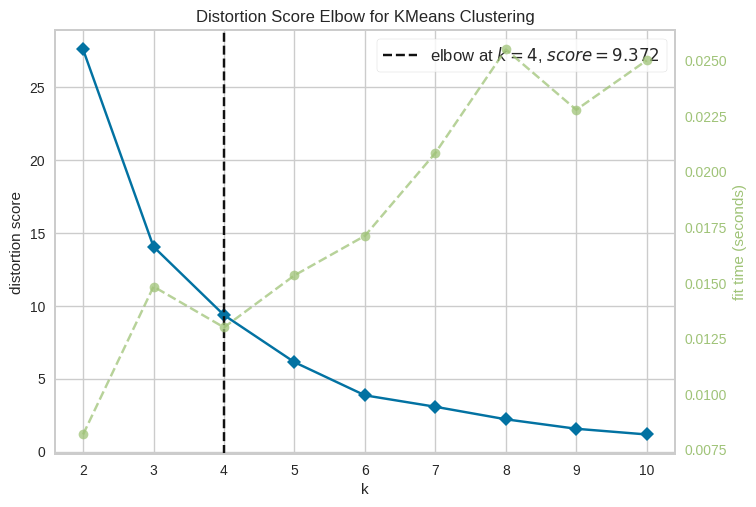

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from yellowbrick.cluster import KElbowVisualizer

print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(KMeans(), k=10)
Elbow_M.fit(new_df.values)
Elbow_M.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(new_df.values)

KMeans(n_clusters=4, random_state=0)

<Axes: xlabel='anorganik', ylabel='sampah_tahunan'>

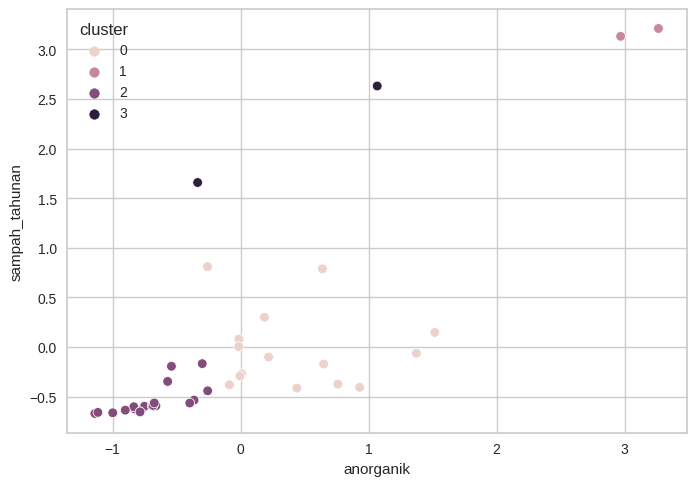

In [ ]:
new_df['target'] = y
new_df['cluster'] = kmeans.labels_

sns.scatterplot(data=new_df, x='anorganik', y='sampah_tahunan', hue='cluster')

Dari Klastering diatas, dapat diambil insight bahwa

- Klaster 0 terdiri dari kab/kota yang memiliki sampah anorganik yang rendah, tetapi memiliki sampah tahunan yang tinggi

- Klaster 1 terdiri dari kab/kota yang memiliki sampah anorganik dan sampah tahunan yang tinggi

- Klaster 2 terdiri dari kab/kota yang memiliki sampah anorganik dan sampah tahunan yang rendah

- Klaster 3 terdiri dari kab/kota yang memiliki sampah anorganik yang tinggi, tetai memiliki sampah tahunan yang rendah

## LOOKERSTUDIO

In [ ]:
df

,tahun,provinsi,kab_kota,sisa_makanan,kayu_ranting,kertas_karton,plastik,logam,kain,karet_kulit,kaca,jenis_lainnya,sampah_harian,sampah_tahunan,anorganik,organik
0,2022,Aceh,Kab. Aceh Selatan,40.50,14.21,11.75,17.59,3.20,2.58,1.95,2.27,7.12,9649.0,3521768.0,39.34,54.71
1,2022,Aceh,Kab. Aceh Tenggara,41.00,11.00,2.00,18.00,2.00,5.00,17.00,4.00,7.12,9132.0,3333297.0,48.00,52.00
2,2022,Aceh,Kab. Aceh Timur,37.00,14.00,5.00,26.00,5.00,3.00,2.00,4.00,4.00,17314.0,6319595.0,45.00,51.00
3,2022,Aceh,Kab. Aceh Barat,41.80,13.30,10.70,18.20,3.10,2.60,1.80,2.00,6.50,10143.0,3702159.0,38.40,55.10
4,2022,Aceh,Kab. Pidie,8.50,7.50,19.30,35.70,4.00,1.00,3.00,2.00,19.00,17780.0,6489773.0,65.00,16.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1032,2019,Maluku Utara,Kota Tidore Kepulauan,34.00,25.00,12.00,11.80,2.30,0.80,1.50,5.80,6.80,4539.0,1656881.0,34.20,59.00
1033,2019,Papua,Kab. Biak Numfor,5.69,33.75,27.83,14.79,13.19,0.02,0.21,4.52,0.00,5817.0,2123205.0,60.56,39.44
1034,2019,Papua,Kota Jayapura,66.39,10.58,4.79,6.60,4.34,2.05,1.08,0.46,3.71,25263.0,9221170.0,19.32,76.97
1035,2019,Papua Selatan,Kab. Asmat,15.00,10.00,30.00,20.00,5.00,5.00,5.00,5.00,5.00,3900.0,1423354.0,70.00,25.00


In [ ]:
df.to_csv('data_sampah_fix.csv', index=False)

https://lookerstudio.google.com/reporting/539f1b23-e163-4c9d-83db-77528dc310d8